# Conical Scanner Validation: AMSR2

This notebook evaluates how well TAT-C's instrument models represent a *conically scanning* radiometer: the Advanced Microwave Scanning Radiometer 2 ([AMSR2](https://www.eorc.jaxa.jp/AMSR/overview/instrument_en.html)) aboard the Japan Aerospace Exploration Agency's (JAXA) Global Change Observation Mission - Water (GCOM-W) satellite. AMSR2's antenna rotates about the nadir axis once every 1.5 s, so its beams sweep a cone at a constant angle from nadir, and the instrument observes during the forward part of each rotation: an arc in front of the sub-satellite point. Every observation is made at the same incidence angle (about 55 deg), which is why conical scanning is common for microwave imagers.

The companion notebooks on cross-track scanners ([ATMS](ValidateImagerATMS.ipynb), [VIIRS](ValidateImagerVIIRS.ipynb)) and side-looking radars ([Sentinel-1C](ValidateSARSentinel1.ipynb), [NISAR](ValidateSARNISAR.ipynb)) found close agreement between those instruments and TAT-C's nadir `Instrument` (a field of regard) and `PointedInstrument` (a rigidly pointed field of view). Neither has the shape of a conical scan. This notebook first asks how closely these models can represent AMSR2, and then evaluates the `ConicalInstrument`, developed in response, which models the scanned cone directly: its cone angle, the sector of scan azimuths it observes, and an along-track field of view that, as for the other instruments, stands in for the motion of the scan over an integration time.

1. **Orbit.** Does TAT-C's propagation of a public two-line element (TLE) set reproduce GCOM-W's position?
2. **Scan geometry.** What cone angle, scan sector, orientation, and timing describe AMSR2's scan?
3. **Footprints.** How do the footprints of the candidate TAT-C instruments compare with the scanned arc and swath?
4. **Observations.** Does `collect_observations` predict which points AMSR2 observes in a day, and when?
5. **Swath coverage.** Do the conical instrument's footprints from `compute_ground_track` reproduce the area AMSR2 scans over an orbit?

## Reference Data

The NASA Global Precipitation Measurement (GPM) mission's Level 1C AMSR2 product ([`GPM_1CGCOMW1AMSR2`](https://disc.gsfc.nasa.gov/datasets/GPM_1CGCOMW1AMSR2_08/summary), version 08), derived from JAXA's Level 1B product and distributed by the NASA Goddard Earth Sciences Data and Information Services Center (GES DISC), holds one file per orbit (about 76 MB). For each of six groups of channels, it gives the geodetic latitude and longitude of every footprint, the scan time, and the spacecraft's geodetic position at each scan. This notebook uses the lowest-frequency group (`S1`, 10.65 GHz, 243 samples per scan), whose footprints span the same scan as the other channels.

All orbits on 26 September 2026 are downloaded (about 1.2 GB; this requires a free [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account and the `earthaccess` package) and reduced to a cache in a local `data/amsr2` directory, so later runs are fast.

GCOM-W is modeled with a TLE from [CelesTrak](https://celestrak.org/) whose epoch (4 October 2026, 07:07 UTC) follows the analysis day by about eight days.

In [1]:
import io
from datetime import datetime, timezone
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import requests

DATA_DIR = Path("data") / "amsr2"
DATA_DIR.mkdir(parents=True, exist_ok=True)
DAY = datetime(2026, 9, 26, tzinfo=timezone.utc)
TLE = [
    "1 38337U 12025A   26277.29678146  .00000240  00000+0  63281-4 0  9990",
    "2 38337  98.2100 216.2278 0001644  77.4488  41.8708 14.57111943764929",
]
CACHE_FILE = DATA_DIR / f"amsr2_l1c_s1_{DAY:%Y%m%d}.npz"

if not CACHE_FILE.exists():
    import earthaccess

    earthaccess.login()
    session = earthaccess.get_requests_https_session()
    granules = requests.get(
        "https://cmr.earthdata.nasa.gov/search/granules.umm_json",
        params={
            "short_name": "GPM_1CGCOMW1AMSR2",
            "version": "08",
            "temporal": f"{DAY:%Y-%m-%d}T00:00:00Z,{DAY:%Y-%m-%d}T23:59:59Z",
            "page_size": 100,
        },
        timeout=120,
    ).json()["items"]
    urls = [
        next(u["URL"] for u in g["umm"]["RelatedUrls"] if u["URL"].startswith("https://data.gesdisc"))
        for g in granules
    ]
    parts = []
    for url in urls:
        with h5py.File(io.BytesIO(session.get(url, timeout=900).content)) as f:
            s1 = f["S1"]
            seconds = (
                pd.to_datetime(
                    pd.DataFrame(
                        {
                            "year": s1["ScanTime/Year"][:],
                            "month": s1["ScanTime/Month"][:],
                            "day": s1["ScanTime/DayOfMonth"][:],
                            "hour": s1["ScanTime/Hour"][:],
                            "minute": s1["ScanTime/Minute"][:],
                            "second": s1["ScanTime/Second"][:],
                            "ms": s1["ScanTime/MilliSecond"][:],
                        }
                    ),
                    utc=True,
                )
                - pd.Timestamp(DAY)
            ).dt.total_seconds().to_numpy()
            parts.append(
                {
                    "time": seconds,
                    "lat": s1["Latitude"][:],
                    "lon": s1["Longitude"][:],
                    "sc_lat": s1["SCstatus/SClatitude"][:],
                    "sc_lon": s1["SCstatus/SClongitude"][:],
                    "sc_alt": s1["SCstatus/SCaltitude"][:],
                }
            )
    reduced = {k: np.concatenate([p[k] for p in parts]) for k in parts[0]}
    # keep each scan once (orbit files overlap), in time order, within the day
    _, first = np.unique(reduced["time"], return_index=True)
    keep = first[(reduced["time"][first] >= 0) & (reduced["time"][first] < 86400)]
    np.savez_compressed(CACHE_FILE, granules=len(urls), **{k: v[keep] for k, v in reduced.items()})

amsr2 = dict(np.load(CACHE_FILE))
pd.Series({"orbit files": int(amsr2["granules"]), "scans": len(amsr2["time"]), "samples per scan": amsr2["lat"].shape[1]})

orbit files            14
scans               49695
samples per scan      243
dtype: int64

## Setup

Times count seconds since 00:00 UTC on the analysis day. The spacecraft's Earth-fixed position is computed from its reported geodetic position at each scan, and its velocity by differencing positions (scans are 1.5 s apart). Helper functions match those of the companion notebooks.

In [2]:
from datetime import timedelta

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from pyproj import Geod, Transformer
from scipy.spatial import cKDTree
from skyfield.framelib import itrs

from tatc.analysis import collect_observations
from tatc.generation import generate_points_fibonacci_lattice
from tatc.constants import EARTH_ROTATION_RATE
from tatc.analysis import compute_ground_track
from tatc.schemas import ConicalInstrument, GeneralPerturbationsOrbit, Instrument, Point, PointedInstrument, Satellite
from tatc.utils import (
    VelocityFrame,
    compute_projected_ray_position,
    field_of_regard_to_swath_width,
    swath_width_to_field_of_regard,
)

GEOD = Geod(ellps="WGS84")
TO_ECEF = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
TO_GEODETIC = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
gcomw = Satellite(name="GCOM-W", orbit=GeneralPerturbationsOrbit.from_tle(TLE))
orbit = gcomw.orbit.to_gp_orbit()
N_SAMPLES = amsr2["lat"].shape[1]


def to_utc(seconds):
    return [DAY + timedelta(seconds=float(s)) for s in np.atleast_1d(seconds)]


def ecef(lon, lat, height=0.0):
    """Earth-fixed position (m) of geodetic coordinates, stacked on the last axis."""
    return np.stack(TO_ECEF.transform(lon, lat, np.broadcast_to(height, np.shape(lon))), axis=-1)


def up(lon, lat):
    """Geodetic up unit vector, stacked on the last axis."""
    lon, lat = np.radians(lon), np.radians(lat)
    return np.stack([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)], axis=-1)


def normalize(x):
    return x / np.linalg.norm(x, axis=-1, keepdims=True)


def inertial_velocity(position, velocity):
    """Inertial velocity expressed in Earth-fixed coordinates."""
    return velocity + EARTH_ROTATION_RATE * np.stack([-position[..., 1], position[..., 0], np.zeros(position.shape[:-1])], axis=-1)


def summarize(x):
    """Summary statistics of a residual sample."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return pd.Series({"n": x.size, "median": np.median(x), "p95 |x|": np.percentile(np.abs(x), 95), "max |x|": np.abs(x).max()})


def binned(x, y, edges, q=(5, 50, 95)):
    """Percentiles of y in bins of x."""
    i = np.digitize(x, edges) - 1
    return np.array([np.percentile(y[i == k], q) if np.any(i == k) else [np.nan] * len(q) for k in range(len(edges) - 1)])


scan_time = amsr2["time"]
sc_pos = ecef(amsr2["sc_lon"].astype(float), amsr2["sc_lat"].astype(float), amsr2["sc_alt"].astype(float) * 1e3)
sc_vel = np.gradient(sc_pos, scan_time, axis=0)
# scans whose neighbors are contiguous (no data gap), for velocities
contiguous = np.r_[np.diff(scan_time) < 2, False] & np.r_[False, np.diff(scan_time) < 2]
foot_lat, foot_lon = amsr2["lat"].astype(float), amsr2["lon"].astype(float)
gaps = [(scan_time[i], scan_time[i + 1]) for i in np.nonzero(np.diff(scan_time) > 60)[0]]

BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b"
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e0",
        "grid.linewidth": 0.6,
    }
)
pd.Series(
    {
        "scans": len(scan_time),
        "scan period (s)": np.median(np.diff(scan_time)),
        "data gaps (UTC)": ", ".join(f"{a / 3600:.2f} to {b / 3600:.2f} h" for a, b in gaps),
        "altitude range (km)": f"{amsr2['sc_alt'].min():.0f} to {amsr2['sc_alt'].max():.0f}",
    }
)

scans                            49695
scan period (s)                    1.5
data gaps (UTC)        8.64 to 11.93 h
altitude range (km)         704 to 732
dtype: object

## Test 1: Orbit

TAT-C's propagated position is compared with the reported spacecraft position at every fiftieth scan, with residuals decomposed along the velocity, to its right, and radially.

In [3]:
i1 = np.nonzero(contiguous)[0][::50]
p1 = np.array(orbit.get_orbit_track(to_utc(scan_time[i1])).frame_xyz_and_velocity(itrs)[0].m).T
offset1 = p1 - sc_pos[i1]
radial1 = normalize(sc_pos[i1])
along1 = normalize(sc_vel[i1] - np.sum(sc_vel[i1] * radial1, axis=-1, keepdims=True) * radial1)
pd.DataFrame(
    {
        "along-track (km)": summarize(np.sum(offset1 * along1, axis=-1) / 1e3),
        "cross-track, right (km)": summarize(np.sum(offset1 * np.cross(along1, radial1), axis=-1) / 1e3),
        "radial (km)": summarize(np.sum(offset1 * radial1, axis=-1) / 1e3),
    }
).T.round(3)

,n,median,p95 |x|,max |x|
along-track (km),994.0,0.118,1.661,1.902
"cross-track, right (km)",994.0,0.002,0.399,0.513
radial (km),994.0,0.004,0.555,0.617


Eight days before its epoch, the TLE reproduces GCOM-W's position to about 1.7 km along track (95th percentile), and to 0.6 km or better across track and radially.

## Test 2: Scan Geometry

For every twentieth scan, the line of sight to each footprint (on the ellipsoid) is computed from the spacecraft position at the scan time and decomposed into a *cone angle* (from the geodetic nadir) and a *scan azimuth* (from the horizontal direction of the velocity, positive to the left), relative to both the Earth-fixed and the inertial velocity. The samples of a scan are taken over about 0.6 s; treating them as simultaneous changes these angles by less than about 0.1 deg.

In [4]:
i2 = np.nonzero(contiguous)[0][::20]
los = normalize(ecef(foot_lon[i2], foot_lat[i2]) - sc_pos[i2, None])
sub_lon, sub_lat, _ = TO_GEODETIC.transform(*sc_pos[i2].T)
nadir = -up(sub_lon, sub_lat)
cone = np.degrees(np.arccos(np.sum(los * nadir[:, None], axis=-1)))


def azimuth(velocity):
    """Scan azimuth (deg) of each line of sight from the horizontal direction of a velocity, positive to the left."""
    forward = normalize(velocity - np.sum(velocity * nadir, axis=-1, keepdims=True) * nadir)
    left = np.cross(forward, nadir)
    horizontal = los - np.sum(los * nadir[:, None], axis=-1, keepdims=True) * nadir[:, None]
    return np.degrees(np.arctan2(np.sum(horizontal * left[:, None], axis=-1), np.sum(horizontal * forward[:, None], axis=-1)))


azimuth_earth = azimuth(sc_vel[i2])
azimuth_inertial = azimuth(inertial_velocity(sc_pos[i2], sc_vel[i2]))
CONE = float(np.median(cone))
SECTOR = float(np.median(azimuth_inertial[:, -1] - azimuth_inertial[:, 0]) / 2)  # half-width (deg)
CENTER = float(np.median(azimuth_inertial[:, -1] + azimuth_inertial[:, 0]) / 2)  # deg
chord = GEOD.inv(foot_lon[i2, 0], foot_lat[i2, 0], foot_lon[i2, -1], foot_lat[i2, -1])[2] / 1e3
ahead = GEOD.inv(np.asarray(sub_lon), np.asarray(sub_lat), foot_lon[i2, N_SAMPLES // 2], foot_lat[i2, N_SAMPLES // 2])[2] / 1e3
center_earth = (azimuth_earth[:, 0] + azimuth_earth[:, -1]) / 2
center_inertial = (azimuth_inertial[:, 0] + azimuth_inertial[:, -1]) / 2
pd.Series(
    {
        "cone angle, median (deg)": CONE,
        "cone angle, std. dev. (deg)": np.std(cone),
        "scan azimuth, first and last sample (deg)": f"{np.median(azimuth_inertial[:, 0]):.2f}, {np.median(azimuth_inertial[:, -1]):.2f}",
        "scan sector center (deg)": CENTER,
        "scan sector half-width (deg)": SECTOR,
        "sample spacing (deg)": np.median(np.diff(azimuth_inertial, axis=1)),
        "arc center offset from Earth-fixed velocity, p95 |x| (deg)": np.percentile(np.abs(center_earth), 95),
        "arc center offset from inertial velocity, p95 |x| (deg)": np.percentile(np.abs(center_inertial), 95),
        "arc center distance ahead of nadir (km)": np.median(ahead),
        "arc end-to-end distance (swath width, km)": np.median(chord),
    }
).round(3)

cone angle, median (deg)                                           47.56447
cone angle, std. dev. (deg)                                        0.097325
scan azimuth, first and last sample (deg)                     -74.83, 75.83
scan sector center (deg)                                           0.497806
scan sector half-width (deg)                                      75.332202
sample spacing (deg)                                               0.622479
arc center offset from Earth-fixed velocity, p95 |x| (deg)         4.301615
arc center offset from inertial velocity, p95 |x| (deg)            0.523279
arc center distance ahead of nadir (km)                           844.47063
arc end-to-end distance (swath width, km)                       1627.163008
dtype: object

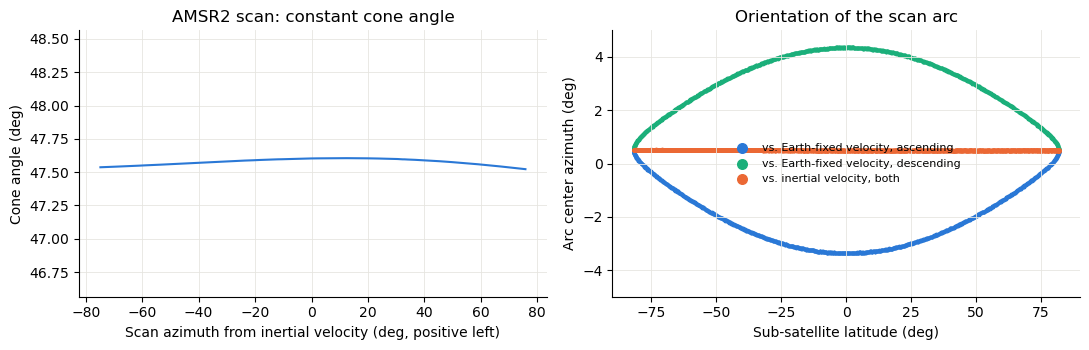

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(np.median(azimuth_inertial, axis=0), np.median(cone, axis=0), color=BLUE)
axes[0].set(xlabel="Scan azimuth from inertial velocity (deg, positive left)", ylabel="Cone angle (deg)", title="AMSR2 scan: constant cone angle", ylim=(CONE - 1, CONE + 1))
asc = sc_vel[i2, 2] > 0
for mask, color, label in [(asc, BLUE, "ascending"), (~asc, AQUA, "descending")]:
    axes[1].scatter(sub_lat[mask], center_earth[mask], s=3, color=color, label=f"vs. Earth-fixed velocity, {label}")
axes[1].scatter(sub_lat, center_inertial, s=3, color=ORANGE, label="vs. inertial velocity, both")
axes[1].set(xlabel="Sub-satellite latitude (deg)", ylabel="Arc center azimuth (deg)", title="Orientation of the scan arc", ylim=(-5, 5))
axes[1].legend(frameon=False, fontsize=8, markerscale=4, loc="center")
fig.tight_layout()
plt.show()

AMSR2's lines of sight lie on a cone 47.56 deg from nadir to within about 0.1 deg across the whole scan (an incidence angle of about 55 deg at the ground). The observed arc spans scan azimuths from -74.8 to +75.8 deg (a sector of about 75.3 deg on either side, sampled every 0.62 deg), centered within about 0.5 deg of the inertial velocity at all latitudes, but up to 4.3 deg from the Earth-fixed velocity: like NOAA-20, GCOM-W keeps its attitude aligned with the orbit plane. The center of the arc lies 844 km ahead of the sub-satellite point, and its ends are 1,627 km apart (the swath width).

## Test 3: Footprints

Three ways of representing AMSR2 with TAT-C's earlier instrument models, and the conical instrument, are compared with the scanned arc:

* **Cone field of regard:** a nadir `Instrument` whose field of regard is twice the cone angle. Its instantaneous footprint is the circle traced by a full rotation of AMSR2's beam; AMSR2 observes the forward part of its boundary.
* **Swath field of regard:** a nadir `Instrument` whose field of regard reproduces the observed swath width (the arc's end-to-end distance) at the median altitude.
* **Pointed view:** a rectangular `PointedInstrument` pitched forward by the cone angle, in the inertial velocity frame, whose cross-track field of view places its edge rays at the cross-track view angles of the arc's ends, with a 1 deg along-track field of view and a field of regard that contains the whole view.

* **Conical instrument:** a `ConicalInstrument` with the measured cone angle and scan sector (center and half width), in the inertial velocity frame, and a 1 deg along-track field of view (its footprint is the region the arc sweeps as the satellite moves along track by the distance this angle subtends at nadir, about 12 km).

In addition, the arc itself is traced with TAT-C's ray projection (`compute_projected_ray_position`): a ray at cone angle `c` and scan azimuth `a` is a rigid rotation from nadir by a roll angle `arctan2(sin(c) sin(a), cos(c))` followed by a pitch angle `arcsin(sin(c) cos(a))`.

In [6]:
altitude = float(np.median(amsr2["sc_alt"])) * 1e3
swath = float(np.median(chord)) * 1e3
c, a = np.radians(CONE), np.radians(SECTOR)
pointed_cross = np.degrees(2 * np.arctan(np.sin(c) * np.sin(a) / (np.cos(c) ** 2 + np.sin(c) ** 2 * np.cos(a))))
# angle from nadir of the pointed view's corners, which its field of regard must contain
pointed_corner = np.degrees(np.arccos(np.cos(c) / np.sqrt(1 + np.tan(np.radians(pointed_cross / 2)) ** 2)))
candidates = {
    "cone field of regard": Instrument(name="AMSR2", field_of_regard=2 * CONE),
    "swath field of regard": Instrument(name="AMSR2", field_of_regard=swath_width_to_field_of_regard(altitude, swath)),
    "pointed view": PointedInstrument(
        name="AMSR2",
        field_of_regard=2 * pointed_corner + 2,
        cross_track_field_of_view=pointed_cross,
        along_track_field_of_view=1,
        pitch_angle=CONE,
        is_rectangular=True,
        velocity_frame=VelocityFrame.INERTIAL,
    ),
    "conical instrument": ConicalInstrument(
        name="AMSR2",
        cone_angle=CONE,
        scan_center_azimuth=CENTER,
        scan_half_width=SECTOR,
        along_track_field_of_view=1,
        velocity_frame=VelocityFrame.INERTIAL,
    ),
}


def arc_rays(azimuth_deg, cone_deg=CONE):
    """Roll and pitch angles (deg) of rays on a cone at scan azimuths (positive left)."""
    c, a = np.radians(cone_deg), np.radians(azimuth_deg)
    return np.degrees(np.arctan2(np.sin(c) * np.sin(a), np.cos(c))), np.degrees(np.arcsin(np.sin(c) * np.cos(a)))


# trace the arc at the median scan azimuth of every sixth sample, at every hundredth scan
i3 = i2[::5]
median_azimuth = np.median(azimuth_inertial, axis=0)
samples3 = np.arange(0, N_SAMPLES, 6)
residual3 = np.zeros((len(i3), len(samples3)))
track3 = orbit.get_orbit_track(to_utc(scan_time[i3]))
for n, j in enumerate(samples3):
    roll, pitch = arc_rays(median_azimuth[j])
    ray = compute_projected_ray_position(track3, 0, 0, roll, pitch, velocity_frame=VelocityFrame.INERTIAL)
    residual3[:, n] = GEOD.inv(ray.longitude.degrees, ray.latitude.degrees, foot_lon[i3, j], foot_lat[i3, j])[2] / 1e3
swath_width = np.vectorize(field_of_regard_to_swath_width)
widths = {
    "cone field of regard": swath_width(amsr2["sc_alt"][i2] * 1e3, 2 * CONE) / 1e3,
    "swath field of regard": swath_width(amsr2["sc_alt"][i2] * 1e3, candidates["swath field of regard"].field_of_regard) / 1e3,
    "conical instrument": np.vectorize(candidates["conical instrument"].get_swath_width)(amsr2["sc_alt"][i2] * 1e3) / 1e3,
}
pd.concat(
    [
        pd.Series(
            {
                "arc traced with roll and pitch, distance to footprints, median (km)": np.median(residual3),
                "arc traced with roll and pitch, distance to footprints, p95 (km)": np.percentile(residual3, 95),
                "swath field of regard (deg)": candidates["swath field of regard"].field_of_regard,
                "pointed view cross-track field of view (deg)": pointed_cross,
            }
        ),
        pd.Series({f"swath width minus observed, {k}, median (km)": np.median(v - chord) for k, v in widths.items()}),
    ]
).round(2)

arc traced with roll and pitch, distance to footprints, median (km)      3.09
arc traced with roll and pitch, distance to footprints, p95 (km)         6.45
swath field of regard (deg)                                             93.41
pointed view cross-track field of view (deg)                           100.56
swath width minus observed, cone field of regard, median (km)           58.30
swath width minus observed, swath field of regard, median (km)          -0.13
swath width minus observed, conical instrument, median (km)              2.83
dtype: float64

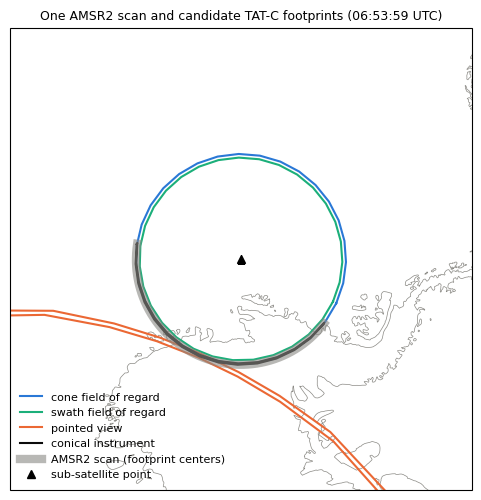

In [7]:
k = i2[len(i2) // 3]
track = orbit.get_orbit_track(to_utc(scan_time[k]))
projection = ccrs.AzimuthalEquidistant(central_longitude=float(amsr2["sc_lon"][k]), central_latitude=float(amsr2["sc_lat"][k]))
fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": projection})
for (name, instrument), color in zip(candidates.items(), [BLUE, AQUA, ORANGE, INK]):
    footprint = instrument.compute_footprint(track)[0]
    for part in getattr(footprint, "geoms", [footprint]):
        ax.plot(*part.exterior.xy, color=color, transform=ccrs.Geodetic(), label=name)
ax.plot(foot_lon[k], foot_lat[k], color=GRAY, lw=6, alpha=0.6, transform=ccrs.Geodetic(), label="AMSR2 scan (footprint centers)")
ax.plot(amsr2["sc_lon"][k], amsr2["sc_lat"][k], "k^", transform=ccrs.Geodetic(), label="sub-satellite point")
ax.coastlines(color=GRAY, linewidth=0.5)
ax.set_extent([-1900e3, 1900e3, -1900e3, 1900e3], crs=projection)
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), frameon=False, fontsize=8, loc="lower left")
ax.set_title(f"One AMSR2 scan and candidate TAT-C footprints ({DAY + timedelta(seconds=float(scan_time[k])):%H:%M:%S} UTC)", fontsize=9)
plt.show()

The scanned arc lies on the forward boundary of the cone field of regard's circular footprint, which therefore has the right geometry where AMSR2 observes, but extends all the way around the circle, beyond the 75 deg scan sector: its swath (the circle's diameter) is 58 km wider than AMSR2's. The swath field of regard reproduces the swath width, but its circle no longer coincides with the cone. The pointed view is a straight strip tangent to the arc at its center, which departs from the arc toward the swath edges and extends far beyond them (its corners are about 64 deg from nadir).

Tracing the arc with roll and pitch angles places TAT-C's rays within 3 km (median) of the footprint centers, comparable to the orbit error and the timing of samples within a scan: TAT-C's ray projection can represent the arc. The conical instrument's footprint is this arc, swept along track; its swath width (the cross-track extent of the arc's ends) is within 3 km of the observed swath.

## Test 4: Observations

`collect_observations` is evaluated for 2,598 points on a Fibonacci lattice with a typical spacing of 500 km.

**Observed.** A point is observed on a pass if it lies within a quadrilateral cell of footprint centers (adjacent samples on consecutive scans), as in the ATMS notebook. Its observation time is the time at which it crosses AMSR2's cone (its angle from nadir equals the measured cone angle, ahead of the spacecraft), computed by bisection on the reported spacecraft trajectory near the nearest scan.

**Predicted.** Each candidate's observations are matched to observed passes of the same point within 10 minutes; predictions during the data gap are excluded. For the nadir instruments, both the `epoch` (the midpoint of the access period, the time of closest approach) and the `start` (when the point enters the field of regard) are compared with the observation time; for the pointed view, the `epoch` (when the view sweeps over the point); and for the conical instrument, the `epoch` (when the point crosses the cone within the scan sector).

In [8]:
foot_unit = up(foot_lon, foot_lat)
tree = cKDTree(foot_unit.reshape(-1, 3))
scan_contiguous = np.diff(scan_time) < 2


def in_cell(points, k, j):
    """Whether unit vectors lie within the quadrilateral of samples (k, j), (k, j+1), (k+1, j+1), (k+1, j)."""
    valid = (k >= 0) & (k < len(scan_time) - 1) & (j >= 0) & (j < N_SAMPLES - 1)
    k, j = np.clip(k, 0, len(scan_time) - 2), np.clip(j, 0, N_SAMPLES - 2)
    valid &= scan_contiguous[k]
    corners = [foot_unit[k, j], foot_unit[k, j + 1], foot_unit[k + 1, j + 1], foot_unit[k + 1, j]]
    signs = np.stack([np.sum(np.cross(p, q) * points, axis=-1) for p, q in zip(corners, corners[1:] + corners[:1])])
    return valid & (np.all(signs >= 0, axis=0) | np.all(signs <= 0, axis=0))


def cone_crossing(target, k):
    """Time (s) at which a target crosses the cone near scan k, by bisection on the reported trajectory."""

    def angle(t):
        i = int(np.clip(np.searchsorted(scan_time, t) - 1, 0, len(scan_time) - 2))
        f = (t - scan_time[i]) / (scan_time[i + 1] - scan_time[i])
        position = sc_pos[i] + f * (sc_pos[i + 1] - sc_pos[i])
        lon, lat, _ = TO_GEODETIC.transform(*position)
        return np.degrees(np.arccos(np.dot(normalize(target - position), -up(lon, lat)))) - CONE

    lower, upper = scan_time[k] - 6, scan_time[k] + 6
    if angle(lower) * angle(upper) > 0:
        return np.nan
    for _ in range(30):
        middle = (lower + upper) / 2
        lower, upper = (middle, upper) if angle(middle) > 0 else (lower, middle)
    return (lower + upper) / 2


points4 = generate_points_fibonacci_lattice(500e3)
point_unit = up(points4.geometry.x.to_numpy(), points4.geometry.y.to_numpy())
observed_rows = []
for p, hits in enumerate(tree.query_ball_point(point_unit, r=2 * np.sin(60 / 6371 / 2), workers=-1)):
    if not hits:
        continue
    hits = np.array(hits)
    k_all = hits // N_SAMPLES
    order = np.argsort(scan_time[k_all])
    hits, k_all = hits[order], k_all[order]
    for group in np.split(np.arange(len(hits)), np.nonzero(np.diff(scan_time[k_all]) > 600)[0] + 1):
        best = hits[group][np.argmin(np.linalg.norm(foot_unit.reshape(-1, 3)[hits[group]] - point_unit[p], axis=-1))]
        k, j = divmod(int(best), N_SAMPLES)
        if not any(in_cell(point_unit[[p]], np.array([k + dk]), np.array([j + dj]))[0] for dk in (-1, 0) for dj in (-1, 0)):
            continue
        target = ecef(points4.geometry.x.iloc[p], points4.geometry.y.iloc[p])
        crossing = cone_crossing(target, k)
        if np.isfinite(crossing):
            observed_rows.append(
                {
                    "point_id": p,
                    "time": pd.Timestamp(DAY) + pd.Timedelta(seconds=float(crossing)),
                    "scan_time": pd.Timestamp(DAY) + pd.Timedelta(seconds=float(scan_time[k])),
                    "azimuth": float(median_azimuth[j]),
                }
            )
observed4 = pd.DataFrame(observed_rows).astype({"point_id": "int64"})


def in_gap(times):
    return np.any([(times >= pd.Timestamp(DAY) + pd.Timedelta(seconds=a)) & (times <= pd.Timestamp(DAY) + pd.Timedelta(seconds=b)) for a, b in gaps], axis=0)


start4, end4 = DAY + timedelta(seconds=float(scan_time[0])), DAY + timedelta(seconds=float(scan_time[-1]))
predicted4, rows4, matched4 = {}, {}, {}
for name, instrument in candidates.items():
    satellite = gcomw.model_copy(update={"instruments": [instrument]})
    predicted = pd.concat(
        [collect_observations(Point(id=p, latitude=g.y, longitude=g.x), satellite, start4, end4) for p, g in enumerate(points4.geometry)]
    ).reset_index(drop=True)
    predicted["point_id"] = predicted.point_id.astype("int64")
    predicted = predicted[~in_gap(predicted.epoch)]
    predicted4[name] = predicted
    for column in ["epoch"] if isinstance(instrument, (PointedInstrument, ConicalInstrument)) else ["epoch", "start"]:
        merged = pd.merge_asof(
            observed4.sort_values("time"),
            predicted[["point_id", column]].rename(columns={column: "predicted"}).sort_values("predicted"),
            left_on="time", right_on="predicted", by="point_id", direction="nearest", tolerance=pd.Timedelta(minutes=10),
        )
        hit = merged.predicted.notna()
        dt = (merged.predicted - merged.time).dt.total_seconds()
        matched4[(name, column)] = merged
        rows4[(name, column)] = {
            "observed": len(observed4),
            "predicted": len(predicted),
            "matched": int(hit.sum()),
            "observed only": int((~hit).sum()),
            "predicted only": len(predicted) - int(hit.sum()),
            "time, median (s)": np.median(dt[hit]),
            "time, p95 |x| (s)": np.percentile(np.abs(dt[hit]), 95),
        }
print(summarize((observed4.time - observed4.scan_time).dt.total_seconds()).rename("cone crossing minus nearest scan time (s)").round(2).to_string())
pd.DataFrame(rows4).T.round(2)

n          4185.00
median        0.09
p95 |x|       1.49
max |x|       2.69


observed  predicted  matched  observed only  \
cone field of regard  epoch    4185.0     4341.0   4179.0            6.0   
                      start    4185.0     4341.0   4179.0            6.0   
swath field of regard epoch    4185.0     4204.0   4154.0           31.0   
                      start    4185.0     4204.0   4154.0           31.0   
pointed view          epoch    4185.0    12262.0   4183.0            2.0   
conical instrument    epoch    4185.0     4180.0   4165.0           20.0   

                             predicted only  time, median (s)  \
cone field of regard  epoch           162.0            109.24   
                      start           162.0              0.21   
swath field of regard epoch            50.0            109.42   
                      start            50.0              5.36   
pointed view          epoch          8079.0            -17.65   
conical instrument    epoch            15.0             -0.02   

                             time, p95 |x| (s)  
cone field of regard  epoch             125.28  
                      start               1.86  
swath field of regard epoch             125.48  
                      start              13.01  
pointed view          epoch              83.68  
conical instrument    epoch               0.27

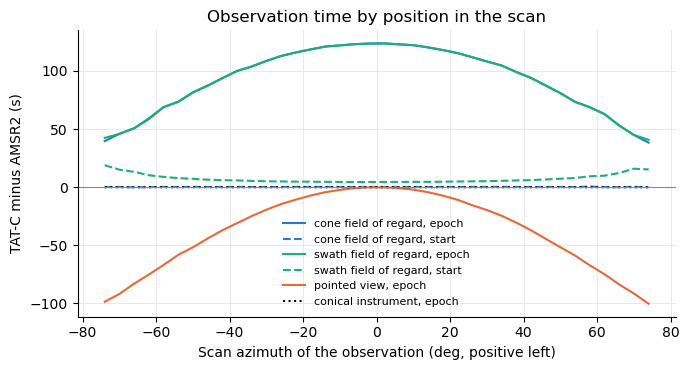

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.8))
edges4 = np.arange(-76, 77, 4)
for (key, merged), color, style in zip(matched4.items(), [BLUE, BLUE, AQUA, AQUA, ORANGE, INK], ["-", "--", "-", "--", "-", ":"]):
    hit = merged.predicted.notna()
    q = binned(merged.azimuth[hit].to_numpy(), (merged.predicted - merged.time).dt.total_seconds()[hit].to_numpy(), edges4)
    ax.plot((edges4[:-1] + edges4[1:]) / 2, q[:, 1], color=color, ls=style, label=f"{key[0]}, {key[1]}")
ax.axhline(0, color=GRAY, lw=0.8)
ax.set(xlabel="Scan azimuth of the observation (deg, positive left)", ylabel="TAT-C minus AMSR2 (s)", title="Observation time by position in the scan")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

The cone field of regard predicts the observed passes almost one for one (4,179 of 4,185 matched), with 3.7% extra predictions from its extra width beyond the scan sector. Its `epoch`, the time of closest approach, is 40 to 125 s later than the actual observation, depending on the position in the scan. Its `start`, however, the time a point enters the field of regard, is the time the point crosses AMSR2's cone: it matches the observation times to 0.2 s (median) and 1.9 s (95th percentile) everywhere in the scan.

The swath field of regard reduces the extra predictions to 1.2%, but its narrower cone delays the `start` by 5 to 19 s. The pointed view sweeps over points at the center of the arc at the right time but up to about 100 s early at the swath edges, and it predicts nearly three times as many passes as were observed.

The conical instrument matches 99.5% of the observed passes (4,165 of 4,185) with only 15 extra predictions (0.4%), and its `epoch` matches the observation times to 0.02 s (median) and 0.27 s (95th percentile) everywhere in the scan. The few unmatched passes are at the swath edges, within a few kilometers of the arc's ends.

## Test 5: Swath Coverage

Over one orbit (starting at 15:00 UTC, after the data gap), the area scanned by AMSR2 (the union of the quadrilaterals formed by adjacent footprint centers on consecutive scans) is compared with the union of the conical instrument's footprints from `compute_ground_track`, at time steps of 1.5 s (one scan), 10 s, and 30 s, on a 0.1 deg grid. The along-track field of view is tailored to each time step as in the other notebooks: the angle subtended at nadir by the distance the satellite's ground track advances in one time step. For comparison, the cone field of regard's circular footprints are evaluated at a 30 s time step. As in the ATMS notebook, the comparison is limited to grid cells within 300 km of a footprint scanned at least 60 s after the start and before the end of the orbit.

In [10]:
from shapely import contains_xy, prepare

orbit_start = 15 * 3600
orbit_period = 86400 / float(TLE[1][52:63])
scans5 = np.nonzero((scan_time >= orbit_start) & (scan_time < orbit_start + orbit_period))[0]
STEP5, MARGIN5 = 0.1, 60  # deg, s
lon5, lat5 = np.meshgrid(np.arange(-180 + STEP5 / 2, 180, STEP5), np.arange(-90 + STEP5 / 2, 90, STEP5))
cell_area5 = (np.cos(np.radians(lat5)) * (STEP5 * 111.32) ** 2).ravel()
grid5 = up(lon5.ravel(), lat5.ravel())
distance5, nearest5 = cKDTree(foot_unit[scans5].reshape(-1, 3)).query(grid5, workers=-1)
nearest_time5 = scan_time[scans5][nearest5 // N_SAMPLES] - scan_time[scans5[0]]
duration5 = scan_time[scans5[-1]] - scan_time[scans5[0]]
compared5 = (distance5 < 2 * np.sin(300 / 6371 / 2)) & (nearest_time5 > MARGIN5) & (nearest_time5 < duration5 - MARGIN5)
observed5 = np.zeros(len(grid5), dtype=bool)
_, nearest_two = cKDTree(foot_unit[scans5].reshape(-1, 3)).query(grid5[compared5], k=2, workers=-1)
for column in range(2):
    k, j = np.divmod(nearest_two[:, column], N_SAMPLES)
    k = scans5[k]
    inside = np.zeros(len(k), dtype=bool)
    for dk in (-1, 0):
        for dj in (-1, 0):
            inside |= in_cell(grid5[compared5], k + dk, j + dj)
    observed5[np.flatnonzero(compared5)] |= inside
ground_speed5 = 2 * np.pi * 6371.0088e3 / orbit_period


def swath_row(instrument, time_step):
    first, last = scan_time[scans5[0]], scan_time[scans5[-1]]
    n = int((last - first) // time_step)
    times = to_utc(first + time_step * (np.arange(n) + 0.5))
    geometry = compute_ground_track(gcomw.model_copy(update={"instruments": [instrument]}), times).geometry.iloc[0]
    prepare(geometry)
    predicted = np.zeros(len(grid5), dtype=bool)
    predicted[compared5] = contains_xy(geometry, lon5.ravel()[compared5], lat5.ravel()[compared5])
    area = lambda mask: np.sum(mask * cell_area5) / 1e6
    return {
        "observed (10^6 km^2)": area(observed5),
        "TAT-C (10^6 km^2)": area(predicted),
        "IoU": area(observed5 & predicted) / area(observed5 | predicted),
        "observed only (%)": 100 * area(observed5 & ~predicted) / area(observed5),
        "TAT-C only (%)": 100 * area(predicted & ~observed5) / area(predicted),
    }


rows5 = {"cone field of regard, 30 s": swath_row(candidates["cone field of regard"], 30)}
for time_step in [1.5, 10, 30]:
    width = np.degrees(2 * np.arctan(ground_speed5 * time_step / 2 / altitude))
    rows5[f"conical instrument, {time_step:g} s ({width:.2f} deg along track)"] = swath_row(
        candidates["conical instrument"].model_copy(update={"along_track_field_of_view": width}), time_step
    )
pd.DataFrame(rows5).T.round(3)

,observed (10^6 km^2),TAT-C (10^6 km^2),IoU,observed only (%),TAT-C only (%)
"cone field of regard, 30 s",64.329,66.296,0.970,0.006,2.973
"conical instrument, 1.5 s (0.81 deg along track)",64.329,63.652,0.986,1.238,0.187
"conical instrument, 10 s (5.42 deg along track)",64.329,63.643,0.986,1.256,0.191
"conical instrument, 30 s (16.18 deg along track)",64.329,63.660,0.985,1.271,0.232


The conical instrument's swath matches the area AMSR2 scans over an orbit with an IoU of 0.986, and, unlike the cone field of regard (whose circles extend 3% beyond the scanned swath), with little area outside it (0.2%). Because its footprint is the arc swept along track by the distance the along-track field of view subtends at nadir, the result is the same for time steps from one scan (1.5 s) to 30 s. About 1.2% of the scanned area is missed, mostly in narrow gaps between consecutive footprints: they tile without margin, and the arc, 844 km ahead of the satellite, moves over the ground slightly faster than the sub-satellite ground track used to tailor the field of view. A slightly larger along-track field of view would close them.

## Summary

| Test | Result |
| --- | --- |
| 1. Orbit (CelesTrak TLE vs. reported position) | 1.7 km along track (95th percentile), eight days before the TLE epoch |
| 2. Scan geometry | cone angle 47.56 deg (within 0.1 deg); scan sector 75.3 deg on either side of a center 0.5 deg left of the *inertial* velocity; arc center 844 km ahead of nadir; swath 1,627 km |
| 3. Footprints | cone field of regard: correct cone, swath 58 km too wide; swath field of regard: correct width, wrong cone; pointed view: straight strip, far wider than the arc; conical instrument: the arc, swath within 3 km |
| 4. Observations (`collect_observations`) | conical instrument: 99.5% of passes matched, 0.4% extra, `epoch` within 0.27 s (95th percentile); cone field of regard: 99.9% matched, 3.7% extra, `start` within 1.9 s but `epoch` 40 to 125 s late; pointed view: up to 100 s early, three times too many passes |
| 5. Swath coverage (`compute_ground_track`) | conical instrument: IoU 0.986 for time steps from 1.5 to 30 s; cone field of regard: IoU 0.970, 3% extra area |

**Existing models.** Because a conical scanner observes along the forward boundary of a cone, a nadir `Instrument` whose field of regard is twice the cone angle identifies nearly every pass, and the `start` of each observation from `collect_observations` (not its `epoch`) is the time AMSR2 observes the point. It cannot represent the scan sector, so its swath is too wide, its `epoch` (used by downstream analyses such as revisit statistics) is up to two minutes late, and its footprints are full circles. A forward-pitched `PointedInstrument` cannot follow the arc and is a poor substitute.

**Conical instrument.** The `ConicalInstrument` closes these gaps. It is specified by a cone angle, a scan sector (a center azimuth and half width, so forward, aft, and full-rotation scanners can be represented), a velocity frame, and an along-track field of view. `collect_observations` reports the time a point crosses the cone within the scan sector as the observation epoch (up to two per pass: entering the cone ahead of the satellite and leaving it behind), and its footprint is the scanned arc, swept along track by the distance the along-track field of view subtends at nadir, as for the tailored fields of view of the other instruments. For AMSR2, with the measured cone angle and scan sector and the inertial velocity frame, it reproduces the observed passes, their times to within a third of a second, the swath width to within 3 km, and the scanned area at any time step tested.